<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [1]:
import io
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

En el aprendizaje no supervisado, solo se dispone de las observaciones ${\mathbf{x}_1, \dots, \mathbf{x}_n}$ sin etiquetas. El objetivo no es predecir, sino descubrir estructura latente en los datos: agrupaciones naturales, relaciones entre variables, o representaciones compactas.

| Feature | Supervised | Unsupervised |
| :--- | :--- | :--- |
| **Data** | $(\mathbf{x}_i, y_i)$ | $\mathbf{x}_i$ |
| **Goal** | Predict $y$ | Discover structure |
| **Requires labels** | Yes | No |
| **Evaluation** | Accuracy, F1, MSE | Silhouette, ARI, NMI |
| **Examples** | Classification, regression | Clustering, dimensionality reduction |

In astronomy, unsupervised learning is particularly relevant because labels are scarce and expensive to obtain. Acquiring a classified spectrum requires hours of telescope time, whereas modern photometric surveys (e.g., LSST, Gaia) produce billions ($10^9$) of unclassified observations.

### Key Applications of Unsupervised Learning

1. **Dimensionality Reduction:** Transforming high-dimensional data into a compact representation that preserves its essential structure.

- PCA (Principal Component Analysis): A linear projection that maximizes data variance.
- t-SNE / UMAP: Non-linear projections that preserve local neighborhood structures.

$$\mathbf{x} \in \mathbb{R}^p \xrightarrow{\text{reduction}} \mathbf{z} \in \mathbb{R}^k, \quad k \ll p$$

2. **Clustering:** Partitioning data into groups of similar objects without prior labels.

- K-Means: Minimizes the Euclidean distance from data points to their respective cluster centroids.
- GMM (Gaussian Mixture Models): Models each cluster as a Gaussian distribution, assigning soft probabilities rather than hard assignments to each data point.
- Hierarchical Clustering: Builds a tree of cluster merges (a dendrogram).

3. **Anomaly Detection:** Identifying objects that do not belong to any known group—such as rare supernovae, asteroids with unusual properties, or unknown optical transients.

### Evaluation Metrics
Evaluating clustering performance without labels is a non-trivial problem. Metrics are generally divided into two families:

1. **Internal Metrics** (do not require labels):

- Silhouette Score: Measures how similar a point is to its own cluster compared to other clusters. $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]$$ where $a(i)$ is the mean distance to the other points in the same cluster, and $b(i)$ is the mean distance to the points in the nearest neighboring cluster.

| Value | Interpretation |
| :--- | :--- |
| $\approx 1$ | Well-clustered (properly assigned) |
| $\approx 0$ | On the decision boundary between clusters |
| $< 0$ | Misclassified (assigned to the wrong cluster) |

2. **External Metrics** (require reference labels):
These are only applicable if external ground-truth classifications are available (e.g., a known taxonomic catalog).

- ARI (Adjusted Rand Index): Measures the fraction of pairs correctly grouped together or separated, adjusted for chance.
$$\text{ARI} \in [-1, 1], \quad 1 = \text{perfect alignment}, \quad 0 = \text{random assignment}$$

- NMI (Normalized Mutual Information): Measures the shared information between the predicted clustering and the true labels, normalized to scale between 0 and 1. $$\text{NMI} = \frac{2 I(C; K)}{H(C) + H(K)} \in [0, 1]$$ (Note: C represents the true classes, K represents the cluster assignments, I is the mutual information, and H is the entropy).

In this analysis, since taxonomic labels for the 1,000 asteroids are unavailable, we will use the Silhouette Score as our primary validation metric.

La taxonomía clásica de asteroides distingue dos tipos principales según su composición:

| Tipo | Albedo $p_v$ | $\log_{10} p_v$ | Composición | Ubicación |
|------|-------------|----------------|-------------|-----------|
| **C** (carbonáceo) | 0.03 – 0.09 | $\lesssim -1.0$ | Rico en carbono, primitivo | Cinturón exterior |
| **S** (silicatado) | 0.10 – 0.35 | $\gtrsim -1.0$ | Silicatos y metales | Cinturón interior |

Esta separación es visible incluso en el histograma de $\log_{10} p_v$, que muestra una distribución bimodal — dos picos separados que sugieren la existencia de dos poblaciones físicamente distintas.



In [2]:
import requests
import pandas as pd
import json

url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"

# Filtros: diameter is defined AND albedo is defined
# Quitamos sb-group porque para asteroides generales no es necesario
filtros = {
    "AND": [
        "diameter|DF",
        "albedo|DF"
    ]
}

params = {
    "fields": "full_name,a,e,i,H,diameter,albedo",
    "sb-cdata": json.dumps(filtros),
    "limit": "1000"
}

print("Consultando JPL (Cinturón Principal + otros)...")

try:
    r = requests.get(url, params=params)
    r.raise_for_status()
    res = r.json()
    
    if 'data' in res:
        df_org = pd.DataFrame(res['data'], columns=res['fields'])
        
        # Convertimos a numérico
        cols_num = ['a', 'e', 'i', 'H', 'diameter', 'albedo']
        df_org[cols_num] = df_org[cols_num].apply(pd.to_numeric, errors='coerce')
        
        # Limpieza de nombres (quitar paréntesis o espacios extra)
        df_org['full_name'] = df_org['full_name'].str.strip()
        
        # Renombrar para tu consistencia en la VAE
        df_org = df_org.rename(columns={'full_name': 'objID', 'diameter': 'D', 'albedo': 'pv'})
        
        print(f"¡Logrado! {len(df_org)} objetos cargados.")
        print(df_org.head())
    else:
        print("La respuesta no contiene datos. Respuesta del servidor:", res)
        
except Exception as e:
    print(f"Error: {e}")
    if 'r' in locals():
        print(f"Texto del servidor: {r.text}")

Consultando JPL (Cinturón Principal + otros)...


¡Logrado! 1000 objetos cargados.
                 objID      a       e      i     H        D      pv
0    1 Ceres (A801 AA)  2.766  0.0796  10.59  3.35  939.400  0.0900
1   2 Pallas (A802 FA)  2.770  0.2306  34.93  4.11  513.000  0.1550
2     3 Juno (A804 RA)  2.671  0.2558  12.99  5.19  246.596  0.2140
3    4 Vesta (A807 FA)  2.362  0.0902   7.14  3.25  522.770  0.4228
4  5 Astraea (A845 XA)  2.577  0.1875   5.36  6.96  106.699  0.2740


In [3]:
df_org.shape, df_org.columns, df_org.head()

((1000, 7),
 Index(['objID', 'a', 'e', 'i', 'H', 'D', 'pv'], dtype='str'),
                  objID      a       e      i     H        D      pv
 0    1 Ceres (A801 AA)  2.766  0.0796  10.59  3.35  939.400  0.0900
 1   2 Pallas (A802 FA)  2.770  0.2306  34.93  4.11  513.000  0.1550
 2     3 Juno (A804 RA)  2.671  0.2558  12.99  5.19  246.596  0.2140
 3    4 Vesta (A807 FA)  2.362  0.0902   7.14  3.25  522.770  0.4228
 4  5 Astraea (A845 XA)  2.577  0.1875   5.36  6.96  106.699  0.2740)

| Parámetro | Descripción | Unidades |
|-----------|-------------|----------|
| `objID` | Identificador del asteroide | — |
| `a` | Semieje mayor orbital | AU |
| `e` | Excentricidad orbital | — |
| `i` | Inclinación orbital respecto al plano eclíptico | grados |
| `H` | Magnitud absoluta (brillo intrínseco) | mag |
| `D` | Diámetro | km |
| `pv` | Albedo geométrico (fracción de luz reflejada) | — |


Las tres variables físicas del asteroide — magnitud absoluta $H$, diámetro $D$ y albedo geométrico $p_v$ — no son independientes. Están vinculadas por la relación empírica:

$$\log_{10} D = \log_{10} 1329 - \frac{1}{2}\log_{10} p_v - \frac{H}{5}$$

Esto significa que conocer dos de ellas determina completamente la tercera. En un análisis de aprendizaje no supervisado, incluir las tres simultáneamente sobrerepresenta la información de tamaño y brillo del asteroide, dándole artificialmente más peso en la separación de grupos.

Por esta razón, se recomienda retener solo H (que combina intrínsecamente ambas propiedades) o bien seleccionar una de las tres según el contexto físico del análisis, evitando redundancia en el espacio de características.

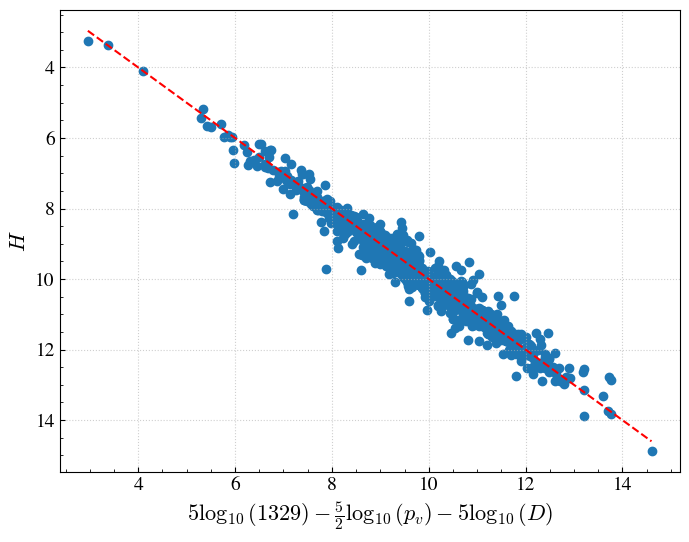

In [4]:
x_combo = -5/2*np.log10(df_org.pv)-5*np.log10(df_org.D) + 5*np.log10(1329)
fig, ax = plt.subplots()
ax.scatter(-5/2*np.log10(df_org.pv)-5*np.log10(df_org.D) + 5*np.log10(1329), df_org.H)
ax.set_xlabel(r'$5\log_{10}(1329) - \frac{5}{2}\log_{10}(p_v) - 5\log_{10}(D)$')
ax.plot([x_combo.min(), x_combo.max()],
        [x_combo.min(), x_combo.max()], 'r--', label='y = x')
ax.set_ylabel(r'$H$')
ax.invert_yaxis()
ax.grid()
plt.show()

In [5]:
df = df_org.drop(['H'],axis=1)
df['sini']  = np.sin(np.radians(df.i))
df['logD']  = np.log10(df.D)
df['logpv'] = np.log10(df.pv)
df = df.drop(['i','D','pv'], axis=1)
df.shape, df.columns, df.head()

((1000, 6),
 Index(['objID', 'a', 'e', 'sini', 'logD', 'logpv'], dtype='str'),
                  objID      a       e      sini      logD     logpv
 0    1 Ceres (A801 AA)  2.766  0.0796  0.183780  2.972851 -1.045757
 1   2 Pallas (A802 FA)  2.770  0.2306  0.572575  2.710117 -0.809668
 2     3 Juno (A804 RA)  2.671  0.2558  0.224781  2.391986 -0.669586
 3    4 Vesta (A807 FA)  2.362  0.0902  0.124294  2.718311 -0.373865
 4  5 Astraea (A845 XA)  2.577  0.1875  0.093413  2.028160 -0.562249)

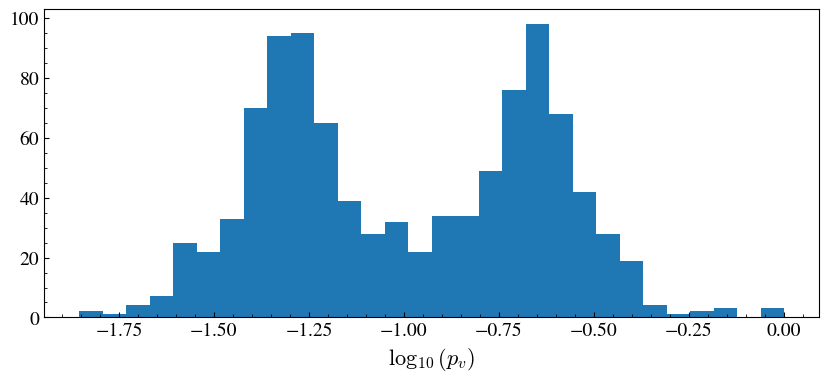

In [6]:
fig, axes = plt.subplots(figsize=(10, 4))
axes.hist(df.logpv, bins=30)
axes.set_xlabel(r'$\log_{10}(p_v)$')
plt.show()

## Dimensional Reduction

### Princiapl Component Analysis (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de transformación lineal que busca un nuevo sistema de coordenadas para los datos. El objetivo es que el primer eje (PC1) capture la mayor cantidad de varianza posible, el segundo (PC2) la segunda mayor, y así sucesivamente. Los nuevos ejes son ortogonales entre sí y están ordenados de mayor a menor varianza explicada.

El PCA requiere que los datos estén centrados en el origen. Si no restamos la media, el primer componente principal apuntaría desde el origen hacia el centro de la nube de puntos, lo cual no captura la varianza interna sino solo la posición media.

Supón que tienes $n$ observaciones y $p$ variables. La matriz de datos es:

$$\mathbf{X} = \begin{pmatrix} x_{11} & x_{12} & \cdots & x_{1p} \\ 
x_{21} & x_{22} & \cdots & x_{2p} \\
 \vdots & & \ddots & \vdots \\ 
x_{n1} & x_{n2} & \cdots & x_{np} 
\end{pmatrix}$$

El vector de medias de cada columna es:

$$\boldsymbol{\mu} = \begin{pmatrix} \mu_1 \\ \mu_2 \\ \vdots \\ \mu_p \end{pmatrix}, \qquad \mu_j = \frac{1}{n}\sum_{i=1}^n x_{ij}$$

La matriz centrada se obtiene restando la media de cada columna:

$$\mathbf{B} = \mathbf{X} - \mathbf{1}\boldsymbol{\mu}^T = \begin{pmatrix} x_{11}-\mu_1 & x_{12}-\mu_2 & \cdots & x_{1p}-\mu_p \\ x_{21}-\mu_1 & x_{22}-\mu_2 & \cdots & x_{2p}-\mu_p \\ \vdots & & \ddots & \vdots \\ x_{n1}-\mu_1 & x_{n2}-\mu_2 & \cdots & x_{np}-\mu_p \end{pmatrix}$$

Ejemplo numérico (4 asteroides, 2 variables: $a$ y $\log p_v$):

$$\mathbf{X} = \begin{pmatrix} 2.5 & -1.4 \\ 3.1 & -1.2 \\ 2.8 & -0.7 \\ 3.4 & -0.6 \end{pmatrix}, \qquad \boldsymbol{\mu} = \begin{pmatrix} 2.95 \\ -0.975 \end{pmatrix}$$

$$\mathbf{B} = \begin{pmatrix} -0.45 & -0.425 \\ 0.15 & -0.225 \\ -0.15 & 0.275 \\ 0.45 & 0.375 \end{pmatrix}$$
---

La matriz de covarianza resume cómo varían conjuntamente las variables:

$$\mathbf{C} = \frac{1}{n-1} \mathbf{B}^T \mathbf{B} = \begin{pmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) & \cdots \\ \text{Cov}(x_2, x_1) & \text{Var}(x_2) & \cdots \\ \vdots & & \ddots \end{pmatrix}$$

- **Diagonal:** varianza de cada variable
- **Fuera de la diagonal:** covarianza entre pares — si es positiva, crecen juntas; si es negativa, una crece cuando la otra decrece

Ejemplo numérico:

$$\mathbf{C} = \frac{1}{3}\mathbf{B}^T\mathbf{B} = \begin{pmatrix} 0.1467 & 0.1192 \\ 0.1192 & 0.1092 \end{pmatrix}$$

La covarianza positiva indica que los asteroides con $a$ mayor tienden a tener $\log p_v$ más alto (menos oscuros).

---

El PCA busca una dirección (vector unitario $\mathbf{w}$) tal que la varianza de los datos proyectados sobre él sea máxima. La varianza proyectada es:

$$\text{Var}(\mathbf{B}\mathbf{w}) = \mathbf{w}^T \mathbf{C}, \mathbf{w}$$

Maximizar esto con la restricción $|\mathbf{w}| = 1$ (usando multiplicadores de Lagrange) lleva a la ecuación de autovalores:

$$\mathbf{C}\mathbf{w} = \lambda\mathbf{w}$$

Los autovalores $\lambda_i$ indican cuánta varianza hay en cada dirección; los autovectores $\mathbf{v}_i$ son esas direcciones.

Ejemplo numérico: para $\mathbf{C}$ de arriba, los autovalores son $\lambda_1 \approx 0.245$, $\lambda_2 \approx 0.011$ y los autovectores:

$$\mathbf{v}_1 = \begin{pmatrix} 0.758 \ 0.652 \end{pmatrix}, \qquad \mathbf{v}_2 = \begin{pmatrix} -0.652 \ 0.758 \end{pmatrix}$$

PC1 apunta en la dirección de mayor dispersión (combinación de $a$ y $\log p_v$); PC2 es perpendicular a PC1.

---

$$\text{Varianza Explicada}k = \frac{\lambda_k}{\sum{i=1}^{p} \lambda_i}$$

Ejemplo: $\lambda_1 + \lambda_2 = 0.256$, entonces PC1 explica $0.245/0.256 \approx 96%$ de la varianza total. Con una sola componente ya capturas casi toda la información.

---

Seleccionamos los $k$ autovectores con mayor autovalor y formamos la matriz de loadings $\mathbf{V}_k \in \mathbb{R}^{p \times k}$:

$$\mathbf{V}_k = \begin{pmatrix} | & | & \cdots \\ \mathbf{v}_1 & \mathbf{v}_2 & \cdots \\ | & | & \cdots \end{pmatrix}$$

Las nuevas coordenadas (scores) de cada observación en el espacio reducido son:

$$\mathbf{Z} = \mathbf{B}\mathbf{V}_k$$

Ejemplo proyectando sobre PC1 ($k=1$):

$$\mathbf{Z} = \begin{pmatrix} -0.45 & -0.425 \\ 0.15 & -0.225 \\ -0.15 & 0.275 \\ 0.45 & 0.375 \end{pmatrix} \begin{pmatrix} 0.758 \ 0.652 \end{pmatrix} = \begin{pmatrix} -0.618 \\ -0.033 \\ 0.066 \\ 0.585 \end{pmatrix}$$

Cada fila es la coordenada del asteroide en el nuevo eje PC1. Lo que era una tabla de 4×2 se redujo a un vector de 4×1 conservando el 96% de la información

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


features = df.columns[1:]
X = df[features]

# 1. Escalamiento
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

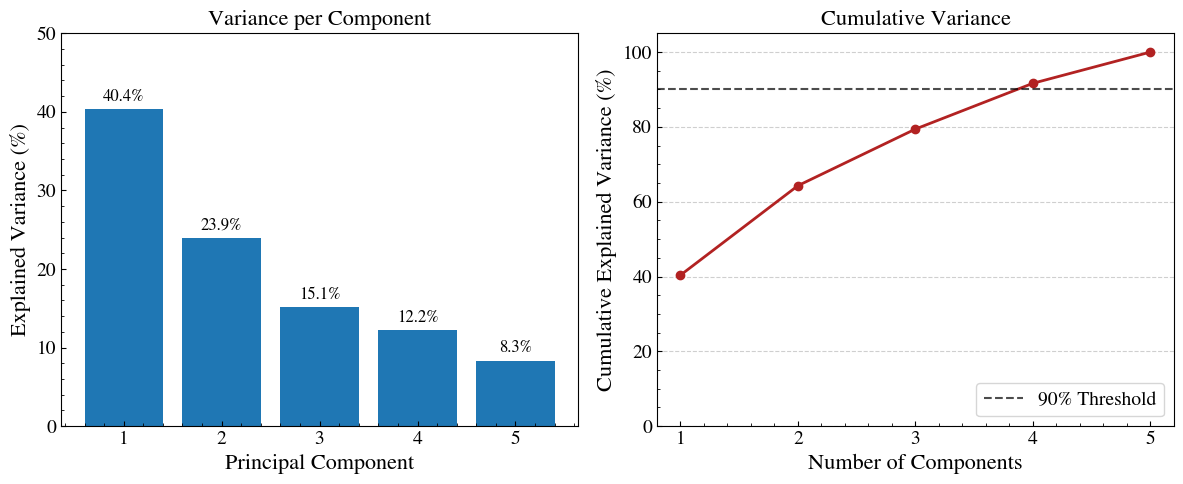

Total Variance Explained by first 2 components: 64.28%


In [8]:
# The maximum number of components is equal to the number of features
n_features = X.shape[1]
pca_full = PCA(n_components=n_features)
pca_full.fit(X_scaled)

# Calculating variance percentages
exp_var_ratio = pca_full.explained_variance_ratio_ * 100
cum_var_ratio = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Individual Explained Variance
bars = axes[0].bar(range(1, n_features + 1), exp_var_ratio)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance per Component')
axes[0].set_xticks(range(1, n_features + 1))
axes[0].set_ylim(0, 50)
# Adding labels over each bar
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)

# 2. Cumulative Explained Variance
axes[1].plot(range(1, n_features + 1), cum_var_ratio, 'o-', color='firebrick', linewidth=2)
axes[1].axhline(90, color='black', linestyle='--', alpha=0.7, label='90% Threshold')


# Adding text for the 90% threshold for clarity
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance')
axes[1].set_xticks(range(1, n_features + 1))
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print summary to console
print(f"Total Variance Explained by first 2 components: {cum_var_ratio[1]:.2f}%")


   Feature        a         e      sini      logD     logpv
------------------------------------------------------------
PC1           0.517    -0.039     0.277     0.588    -0.555
PC2          -0.110     0.773     0.616    -0.095     0.050


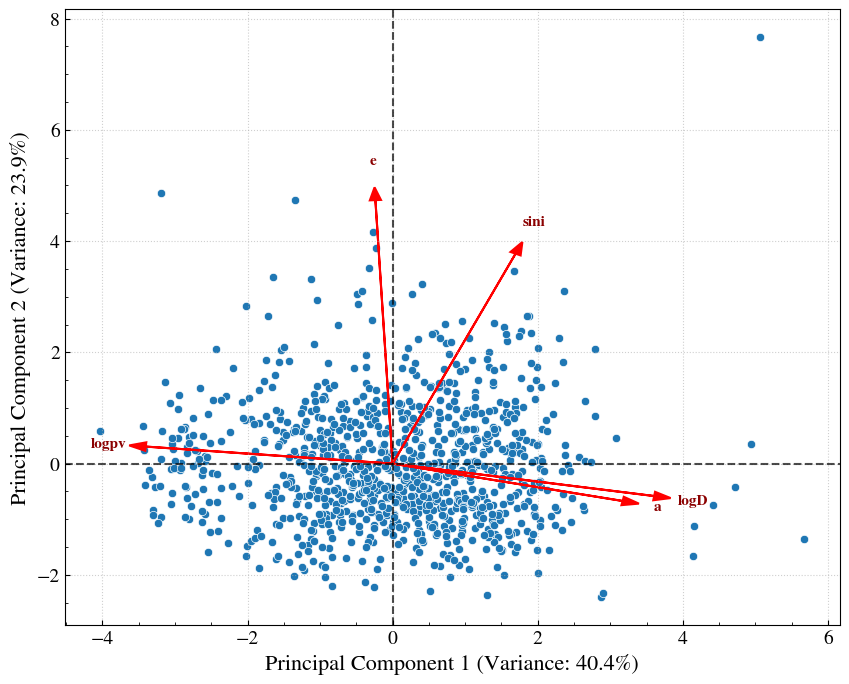

In [9]:
# --- PCA Execution ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Print Loading Matrix (Component Weights) ---
loadings = pca.components_
print(f"\n{'Feature':>10} " + "  ".join(f"{f:>8}" for f in features))
print("-" * (10 + 10 * len(features)))
for i, row in enumerate(loadings):
    print(f"PC{i+1:<8} " + "  ".join(f"{v:>8.3f}" for v in row))

# --- Biplot Scaling Calculation ---
# Scale arrows to match the score distribution (80% of max score)
max_score = np.max(np.abs(X_pca))
scaling_factor = max_score * 0.8 

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot of asteroid scores
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=ax)

# Project original features as vectors (arrows)
for i, feature in enumerate(features):
    x_vec = loadings[0, i] * scaling_factor
    y_vec = loadings[1, i] * scaling_factor
    
    # Draw arrow from origin
    ax.arrow(0, 0, x_vec, y_vec, color='red', 
             head_width=max_score*0.02, head_length=max_score*0.03, lw=1.5)
    
    # Feature labels with slight offset
    ax.text(x_vec * 1.15, y_vec * 1.15, feature, color='darkred', 
            ha='center', va='center', fontweight='bold', fontsize=11)

# --- Plot Formatting ---
ax.axhline(0, color='black', linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linestyle='--', alpha=0.7)

# Dynamic labels with explained variance
var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'Principal Component 1 (Variance: {var_exp[0]:.1f}%)')
ax.set_ylabel(f'Principal Component 2 (Variance: {var_exp[1]:.1f}%)')

ax.grid(True, linestyle=':', alpha=0.6)
plt.show()

La dirección y longitud de cada flecha indica cuánto y en qué sentido contribuye cada variable a PC1 y PC2.

**PC1 (eje horizontal, 38.8%)**: Separa principalmente por tamaño y tipo taxonómico.

- `a` y logD apuntan hacia la derecha → asteroides grandes con órbitas externas (cinturón exterior)
- `logpv` apunta hacia la izquierda → alto albedo se asocia con asteroides más pequeños y brillantes (tipo S, cinturón interior)
- `logpv` es casi opuesto a `a` y logD: los asteroides más grandes tienden a ser oscuros (tipo C), los más brillantes tienden a ser pequeños

**PC2 (eje vertical, 21.1%):** Captura la geometría orbital.

- `sini` apunta hacia arriba → órbitas muy inclinadas
- e apunta hacia abajo → alta excentricidad
- Son casi opuestos: existe un tradeoff entre inclinación y excentricidad en las familias orbitales

| Par | Ángulo | Interpretación |
|-----|--------|----------------|
| `a` — `logD` | ~pequeño | Correlacionadas: asteroides grandes están en el cinturón exterior |
| `logpv` — `logD` | ~180° | Anti-correladas: mayor tamaño → menor albedo |
| `sini` — `e` | ~opuestos | Anti-correladas en PC2 |
| `sini` — `a` | ~90° | Independientes |


**Nube de puntos:** No se ven clusters separados claramente en 2D — esto es esperado porque PC1+PC2 solo explican el 59.9% de la varianza. La estructura de grupos estará más definida en las 4 dimensiones que elegiste para el clustering.

### (Uniform Manifold Approximation and Projection) UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensión no lineal. A diferencia del PCA (que solo encuentra direcciones lineales), UMAP puede capturar estructuras curvas y no lineales en los datos.

La idea central: preservar la topología local — puntos que son vecinos en alta dimensión deben seguir siendo vecinos en 2D.

¿Es mejor que PCA para ver clusters?
PCA	UMAP
Tipo	Lineal	No lineal
Preserva	Varianza global	Estructura local/vecindad
Clusters	Los comprime, puede solaparlos	Los separa visualmente mejor
Interpretable	Sí (loadings)	No — los ejes no tienen significado físico
Determinista	Sí	No (depende de random_state)
Velocidad	Rápido	Más lento
UMAP es mejor para visualizar clusters, pero no debes hacer clustering directamente sobre el embedding UMAP — las distancias entre grupos se distorsionan. Úsalo solo para visualización.

In [10]:
try: 
    import umap
except:
    !pip install umap-learn
    import umap

True


/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


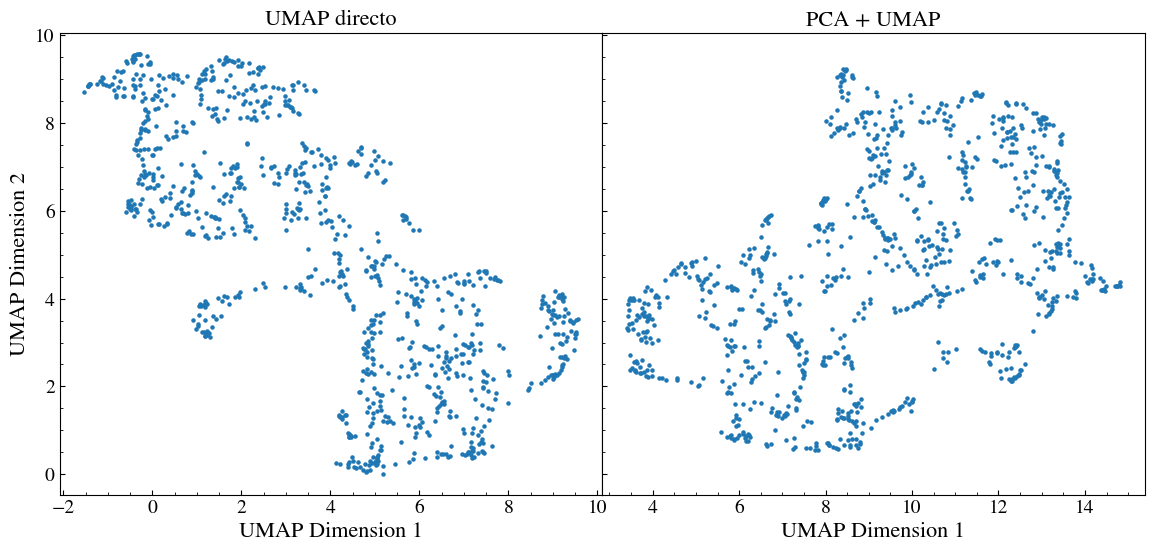

In [12]:
# 1. Dimensionality Reduction Pre-processing
# Applying PCA to reduce noise and capture 4 main components before UMAP
pca4   = PCA(n_components=4)
X_pca4 = pca4.fit_transform(X_scaled)
print(hasattr(pca4, 'explained_variance_ratio_'))
# 2. UMAP Embedding Generation
# We initialize one reducer. Using a random_state ensures reproducibility.
reducer = umap.UMAP(random_state=42)

# Embedding 1: Direct UMAP on scaled features
# This captures the non-linear manifold of the raw (scaled) data
original_embedding = reducer.fit_transform(X_scaled)

# Embedding 2: UMAP on PCA-preprocessed data
# Common practice to speed up computation and filter noise
pca_pre_embedding = reducer.fit_transform(X_pca4)

# 3. Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'wspace': 0})
axes[0].scatter(original_embedding[:, 0], original_embedding[:, 1],s=5)
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')
axes[0].set_title('UMAP directo')

sc1 = axes[1].scatter(pca_pre_embedding[:, 0], pca_pre_embedding[:, 1],s=5)
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_title('PCA + UMAP')
axes[1].tick_params(labelleft=False)

plt.show()

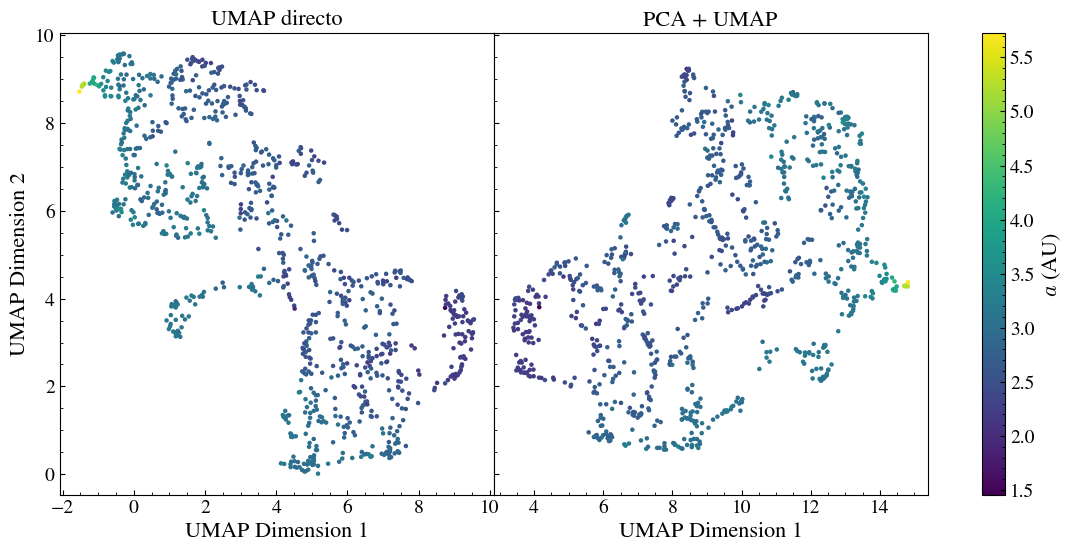

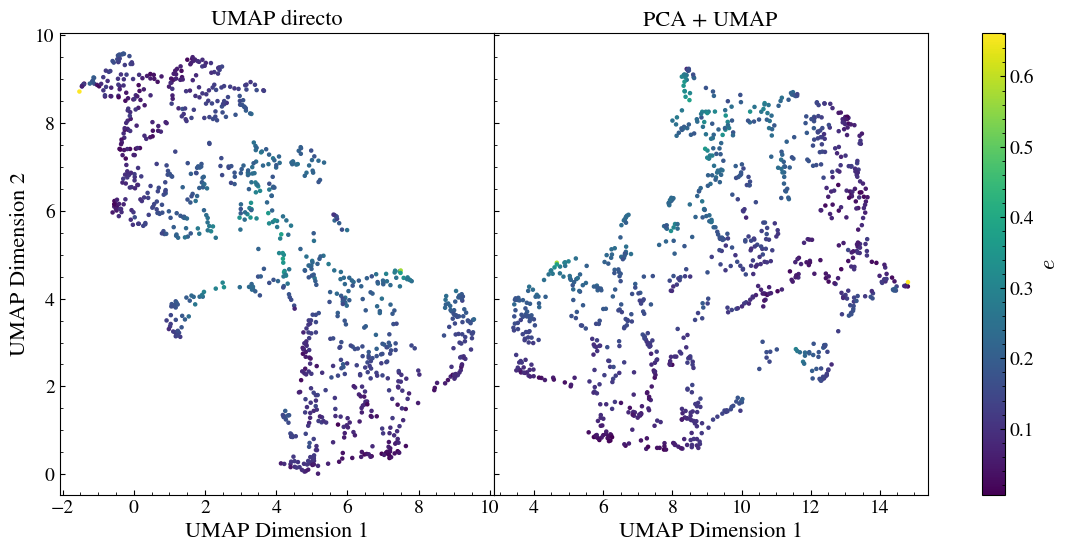

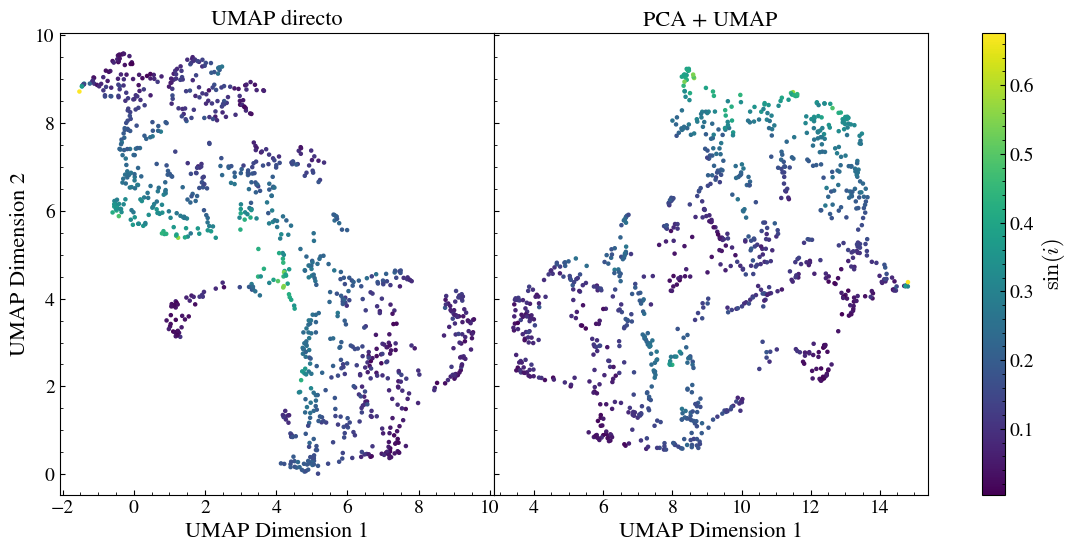

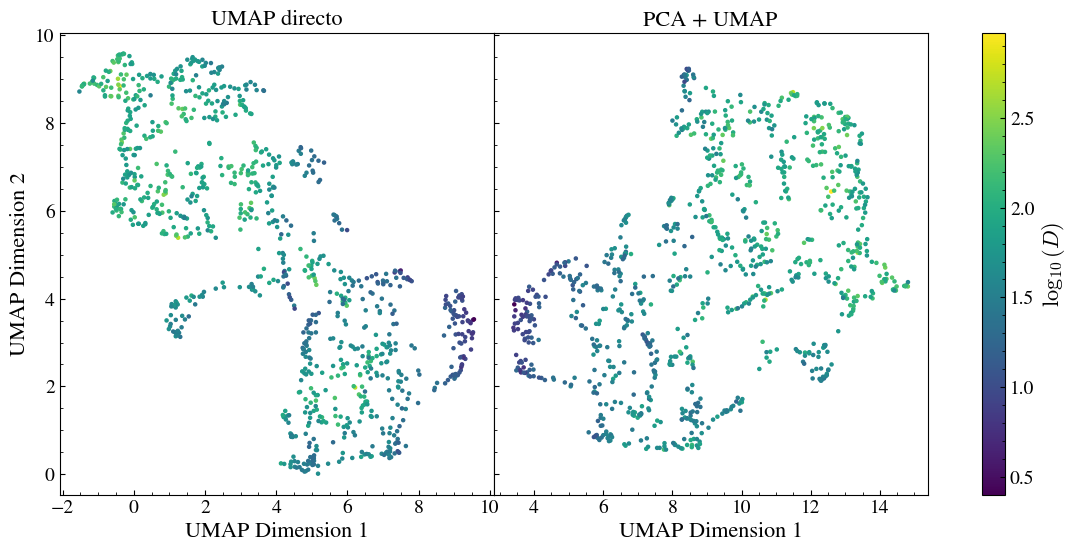

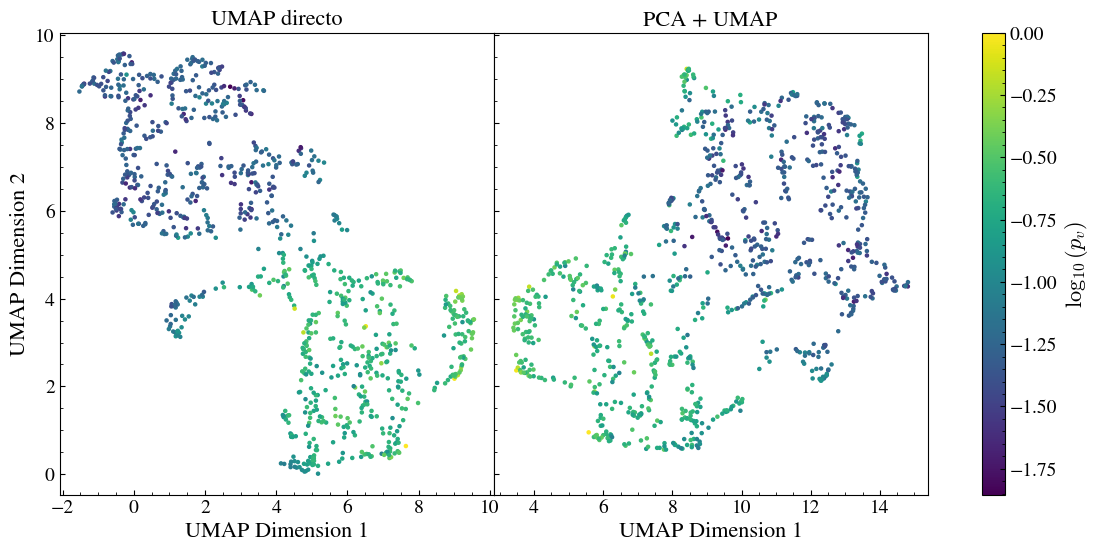

In [13]:
# Mapeo de variables a su transformación y etiqueta
feature_config = {
    'a':    (lambda x: x,           '$a$ (AU)'),
    'e':    (lambda x: x,           '$e$'),
    'sini': (lambda x: x,           r'$\sin(i)$'),       # si ya está transformada
    'logD': (lambda x: x,           r'$\log_{10}(D)$'),  # si ya está transformada
    'logpv':(lambda x: x,           r'$\log_{10}(p_v)$'),
}


for feature, (transform, label) in feature_config.items():
    color_var = transform(df[feature])
    vmin, vmax = color_var.min(), color_var.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'wspace': 0})

    sc0 = axes[0].scatter(original_embedding[:, 0], original_embedding[:, 1],
                          c=color_var, s=5, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_xlabel('UMAP Dimension 1')
    axes[0].set_ylabel('UMAP Dimension 2')
    axes[0].set_title('UMAP directo')

    sc1 = axes[1].scatter(pca_pre_embedding[:, 0], pca_pre_embedding[:, 1],
                          c=color_var, s=5, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_xlabel('UMAP Dimension 1')
    axes[1].set_title('PCA + UMAP')
    axes[1].tick_params(labelleft=False)

    fig.colorbar(sc1, ax=axes, label=label)
    plt.show()


## Clustering

### K-Means

K-means es un algoritmo de aprendizaje no supervisado que busca particionar un conjunto de $n$ observaciones en $k$ grupos disjuntos. La idea central es que cada observación pertenece al clúster cuyo centroide (media aritmética) es el más cercano en distancia euclidiana. El hiperparámetro fundamental del modelo es precisamente $k$ — el número de clústeres — que debe fijarse antes de entrenar y no es aprendido por el algoritmo. Elegir $k$ adecuadamente es parte central del análisis, y se hace con criterios como el método del codo o el silhouette score.

Dado un conjunto de puntos ${\mathbf{x}_1, \dots, \mathbf{x}_n} \subset \mathbb{R}^p$, queremos encontrar $k$ centroides ${\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k}$ y una asignación $S_1, \dots, S_k$ que minimicen la inercia (WCSS — Within-Cluster Sum of Squares):

$$J = \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} |\mathbf{x} - \boldsymbol{\mu}_i|^2$$

donde:

- $S_i$ es el conjunto de puntos asignados al clúster $i$, con $S_i \cap S_j = \emptyset$ y $\bigcup_i S_i = {\mathbf{x}_1,\dots,\mathbf{x}_n}$ 
- $\boldsymbol{\mu}_i \in \mathbb{R}^p$ es el centroide del clúster $i$
- $|\mathbf{x} - \boldsymbol{\mu}i|^2 = \displaystyle{\sum_{d=1}^{p}(x_d - \mu_{id})^2}$ es la distancia euclidiana al cuadrado.

| Asteroide | $a$ | $e$ | $\sin i$ | $\log_{10} D$ | $\log_{10} p_v$ |
|-----------|-----|-----|----------|---------------|-----------------|
| Ceres     | 2.766 | 0.080 | 0.184 | 2.973 | −1.046 |
| Pallas    | 2.770 | 0.231 | 0.572 | 2.710 | −0.810 |
| Vesta     | 2.362 | 0.090 | 0.124 | 2.718 | −0.374 |


Cada asteroide es un vector en $\mathbb{R}^5$, por ejemplo:

$$\mathbf{x}_\text{Ceres} = (2.766,\ 0.080,\ 0.184,\ 2.973,\ {-1.046})$$

Si K-means agrupa Ceres y Pallas en el mismo clúster $S_1$, el centroide es su promedio coordenada a coordenada:

$$\boldsymbol{\mu}_1 = \frac{\mathbf{x}_\text{Ceres} + \mathbf{x}_\text{Pallas}}{2} = (2.768,\ 0.156,\ 0.378,\ 2.842,\ {-0.928})$$

Este centroide representa un asteroide "promedio" del grupo: semieje $\sim 2.77$ AU, órbita poco excéntrica, inclinación moderada, diámetro grande ($10^{2.84} \approx 700$ km) y albedo bajo (tipo C).

La contribución de Vesta a la inercia respecto a $\boldsymbol{\mu}_1$ sería:

$$|\mathbf{x}_\text{Vesta} - \boldsymbol{\mu}_1|^2 = (2.362-2.768)^2 + (0.090-0.156)^2 + \cdots \approx 0.82$$

Un valor alto indica que Vesta está lejos de ese centroide — lo que K-means interpretaría como que pertenece a otro clúster.

**¿Cómo elegir el número de clústeres ($k$)?:** En aprendizaje no supervisado, no hay una "respuesta correcta" única, pero usamos dos métricas estándar para decidir:A. El Método del Codo (Elbow Method)Calculamos la Inercia (o $WCSS$: Within-Cluster Sum of Squares), que es la suma de las distancias al cuadrado de cada punto a su centroide. A medida que $k$ aumenta, la inercia baja. Buscamos el punto donde la mejora deja de ser drástica.B. Coeficiente de Silueta (Silhouette Score)Mide qué tan parecido es un objeto a su propio clúster en comparación con otros clústeres. Un valor cercano a 1 indica que el objeto está bien emparejado


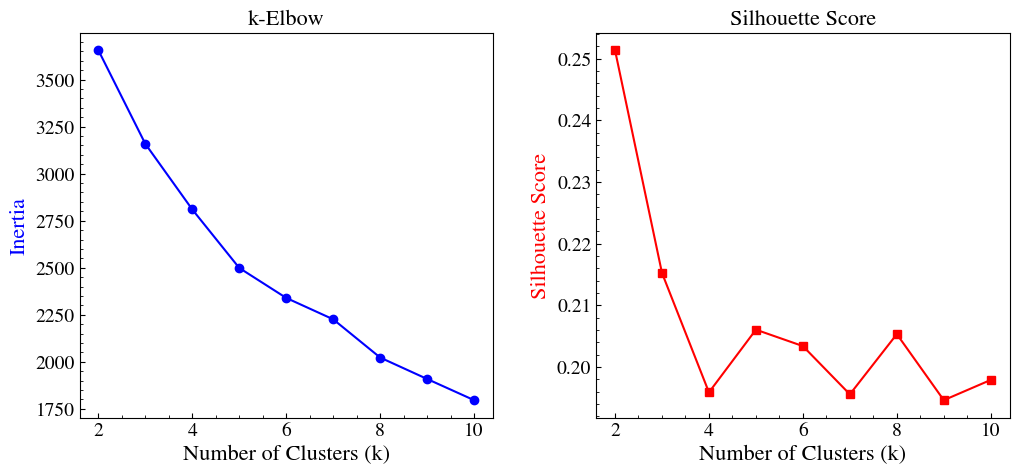

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_pts = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_pts.append(silhouette_score(X_scaled, labels))

# Plotting the Elbow and Silhouette
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12, 5), gridspec_kw={'wspace':.25})
ax1.plot(k_range, inertia, 'o-', color='blue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='blue')
ax1.set_title('k-Elbow')

ax2.plot(k_range, silhouette_pts, 's-', color='red', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_title('Silhouette Score')

plt.show()

Método del codo (izquierda)

La inercia baja continuamente sin un quiebre brusco — no hay un "codo" claro. Esto indica que los datos no tienen grupos muy compactos y bien separados; la estructura es gradual, no discreta.

Silhouette score (derecha)

$k$	Observación
$k=2$	Máximo global (~0.25) → mejor separación relativa
$k=3$	Caída brusca → agregar un tercer grupo fragmenta clusters naturales
$k=5$	Máximo local (~0.212) → segunda mejor opción
$k \geq 6$	Valores bajos y decrecientes
Conclusión
Ambos criterios apuntan a $k=2$ como la solución más robusta, lo que es físicamente consistente con la bimodalidad que ya vimos en el histograma de $\log p_v$: la separación natural entre asteroides tipo C (oscuros) y tipo S (brillantes).

Sin embargo, los valores de silhouette son todos menores a 0.25 — una referencia de estructura débil. Esto significa que los clusters se solapan y no tienen fronteras nítidas, lo cual es esperable: las familias de asteroides no están separadas por fronteras abruptas en el espacio de features, sino que se mezclan gradualmente

The Silhouette Score suggests that a binary classification ($k=2$) is the most robust, likely reflecting the major taxonomic split (S-type vs C-type). However, the Elbow Method indicates that a value of $k=3$ or $k=4$ captures significantly more structural detail without over-segmenting the data, which is better for identifying dynamical families."

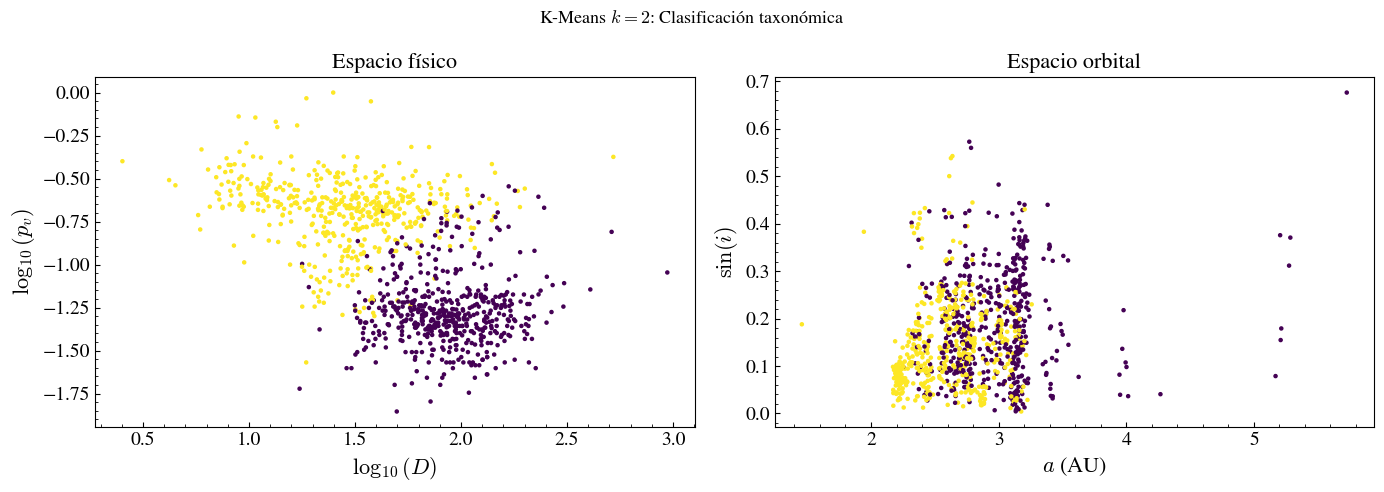

In [23]:
from sklearn.cluster import KMeans

# Probemos con 2 clusters (puedes cambiar este número)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Espacio físico: donde vive la separación C vs S
axes[0].scatter(df['logD'], df['logpv'], c=df['cluster'], s=5, cmap='viridis')
axes[0].set_xlabel(r'$\log_{10}(D)$')
axes[0].set_ylabel(r'$\log_{10}(p_v)$')
axes[0].set_title('Espacio físico')

# Espacio orbital: para ver si hay separación también aquí
axes[1].scatter(df['a'], df['sini'], c=df['cluster'], s=5, cmap='viridis')
axes[1].set_xlabel('$a$ (AU)')
axes[1].set_ylabel(r'$\sin(i)$')
axes[1].set_title('Espacio orbital')

plt.suptitle('K-Means $k=2$: Clasificación taxonómica', fontsize=13)
plt.tight_layout()
plt.show()

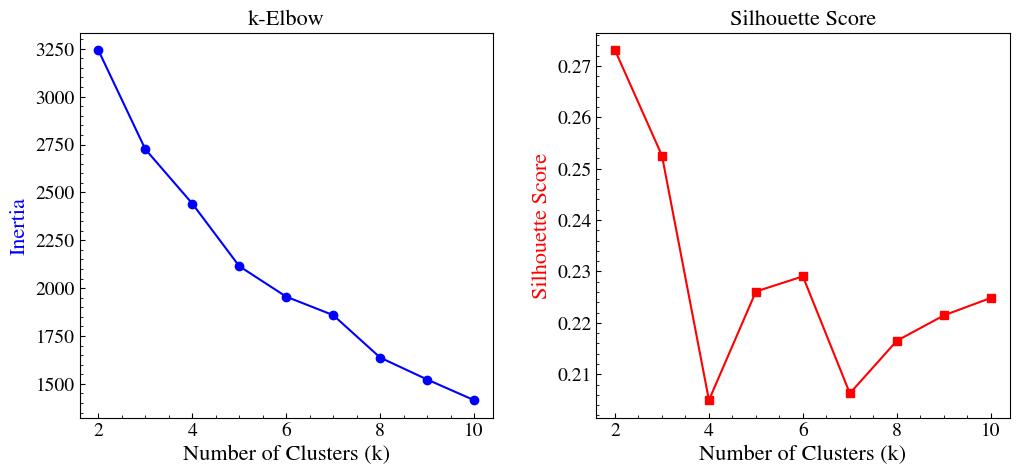

In [19]:
# Usanod ahora sobre PCA4
inertia = []
silhouette_pts = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca4)
    inertia.append(km.inertia_)
    silhouette_pts.append(silhouette_score(X_pca4, labels))

# Plotting the Elbow and Silhouette
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12, 5), gridspec_kw={'wspace':.25})
ax1.plot(k_range, inertia, 'o-', color='blue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='blue')
ax1.set_title('k-Elbow')

ax2.plot(k_range, silhouette_pts, 's-', color='red', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_title('Silhouette Score')

plt.show()

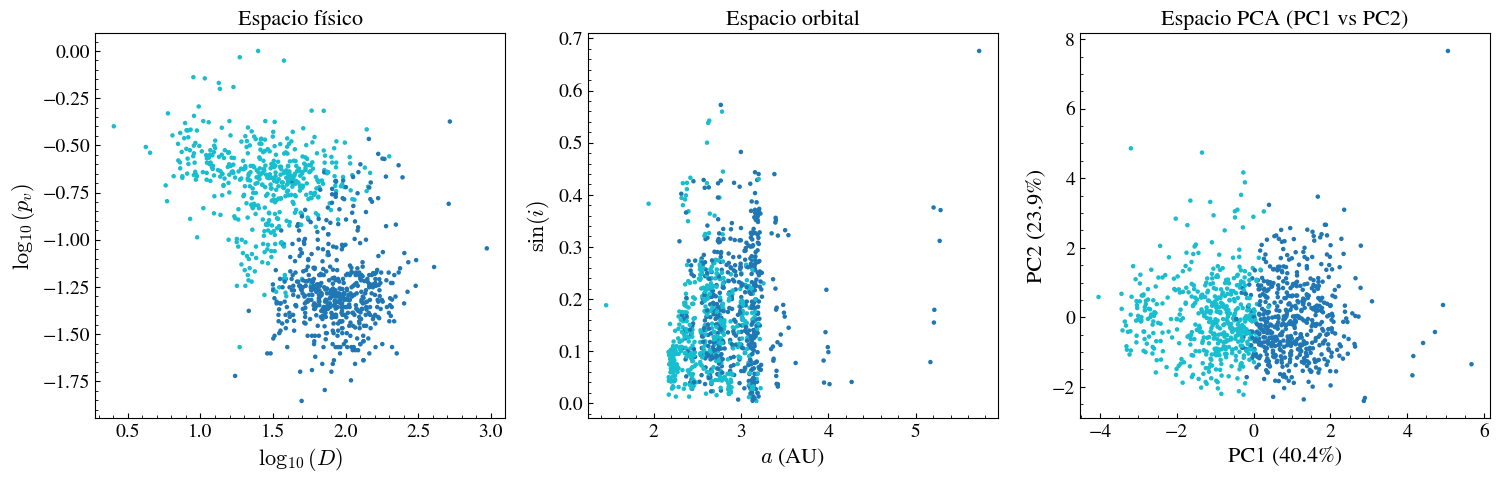

In [20]:
from sklearn.cluster import KMeans

# Probemos con 2 clusters (puedes cambiar este número)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Espacio físico
axes[0].scatter(df['logD'], df['logpv'], c=df['cluster'], s=5, cmap='tab10')
axes[0].set_xlabel(r'$\log_{10}(D)$')
axes[0].set_ylabel(r'$\log_{10}(p_v)$')
axes[0].set_title('Espacio físico')

# Espacio orbital
axes[1].scatter(df['a'], df['sini'], c=df['cluster'], s=5, cmap='tab10')
axes[1].set_xlabel('$a$ (AU)')
axes[1].set_ylabel(r'$\sin(i)$')
axes[1].set_title('Espacio orbital')

# Espacio PCA (donde ocurrió el clustering)
axes[2].scatter(X_pca4[:, 0], X_pca4[:, 1], c=df['cluster'], s=5, cmap='tab10')
axes[2].set_xlabel(f'PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_title('Espacio PCA (PC1 vs PC2)')

plt.show()

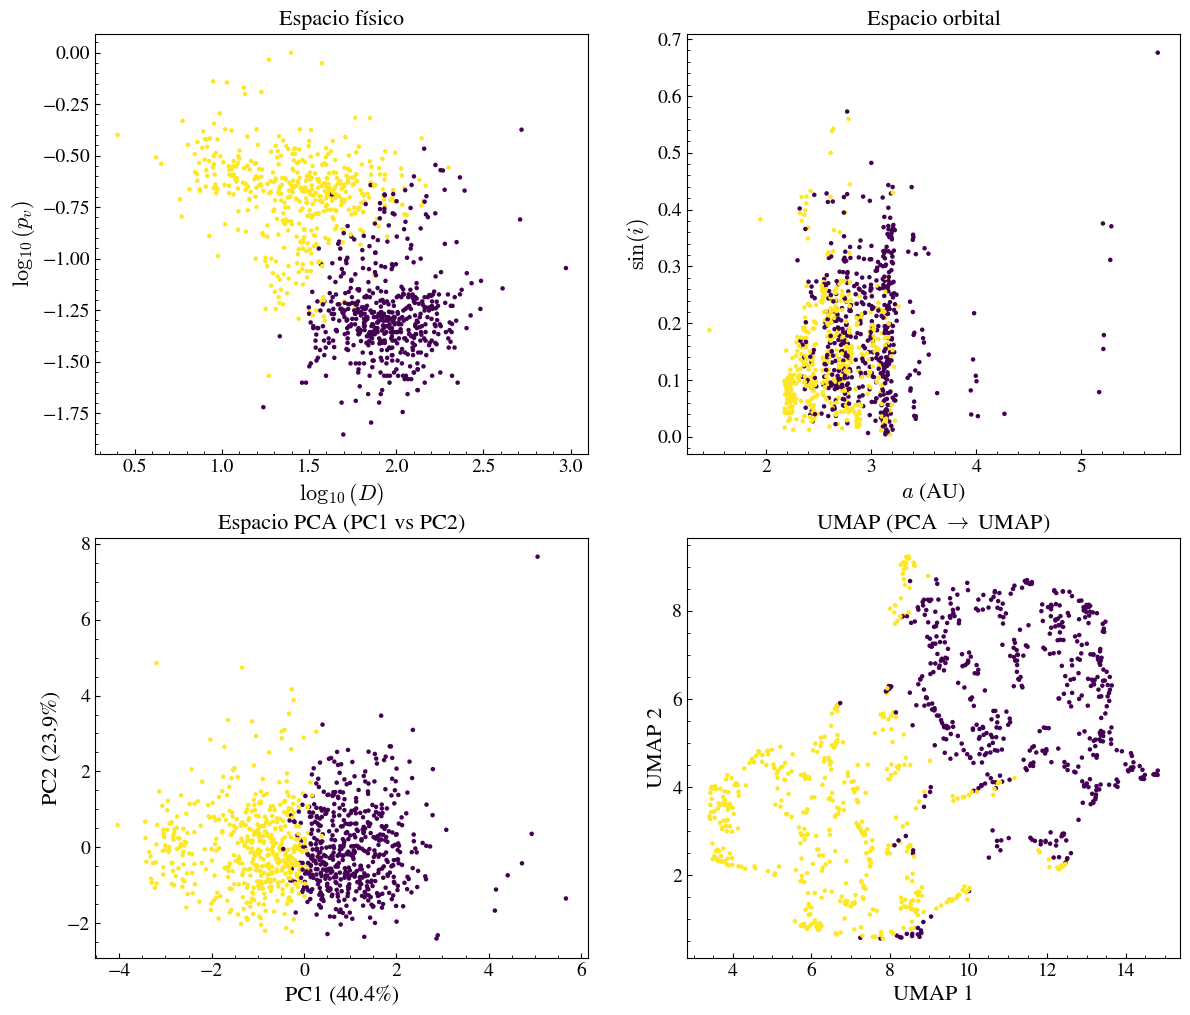

In [22]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca4)

# UMAP sobre PCA4
embedding_pca = reducer.fit_transform(X_pca4)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Espacio físico
axes[0,0].scatter(df['logD'], df['logpv'], c=df['cluster'], s=5, cmap='viridis')
axes[0,0].set_xlabel(r'$\log_{10}(D)$')
axes[0,0].set_ylabel(r'$\log_{10}(p_v)$')
axes[0,0].set_title('Espacio físico')

# Espacio orbital
axes[0,1].scatter(df['a'], df['sini'], c=df['cluster'], s=5, cmap='viridis')
axes[0,1].set_xlabel('$a$ (AU)')
axes[0,1].set_ylabel(r'$\sin(i)$')
axes[0,1].set_title('Espacio orbital')

# Espacio PCA
axes[1,0].scatter(X_pca4[:, 0], X_pca4[:, 1], c=df['cluster'], s=5, cmap='viridis')
axes[1,0].set_xlabel(f'PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,0].set_ylabel(f'PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,0].set_title('Espacio PCA (PC1 vs PC2)')

# UMAP
axes[1,1].scatter(embedding_pca[:, 0], embedding_pca[:, 1], c=df['cluster'], s=5, cmap='viridis')
axes[1,1].set_xlabel('UMAP 1')
axes[1,1].set_ylabel('UMAP 2')
axes[1,1].set_title('UMAP (PCA $\\rightarrow$ UMAP)')

plt.show()


### Gaussian Mixture Models (GMM)

Un GMM supone que los datos fueron generados por $K$ distribuciones gaussianas mezcladas. En lugar de asignar cada punto a un único cluster (como K-means), asigna probabilidades de pertenencia a cada componente.

Dado un dataset $\mathbf{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_n\}$ en $D$ dimensiones, suponemos que la densidad de probabilidad es:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

donde:

- $\pi_k$ son los pesos de mezcla: $0 \leq \pi_k \leq 1$, $\sum_k \pi_k = 1$
- $\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$ es la gaussiana multivariada del componente $k$:

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}} \exp!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

Para cada observación $\mathbf{x}_n$ existe una variable latente $z_{nk} \in {0,1}$ que indica si fue generada por el componente $k$. Como no la observamos, calculamos su esperanza: la responsabilidad:

$$\gamma(z_{nk}) = \frac{\pi_k \,\mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\displaystyle\sum_{j=1}^{K} \pi_j \,\mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

Ceres tiene 98.6% de probabilidad de pertenecer al componente 1 (tipo C) y solo 1.4% al componente 2 — mucho más informativo que la asignación binaria de K-means.

Este es el núcleo del soft clustering: cada punto tiene una fracción de pertenencia a cada grupo.

Ejemplo numérico con 4 asteroides en 1D ($\log_{10} p_v$), $K=2$, $\sigma=0.3$, inicialización $\mu_1^{(0)}=-1.6$, $\mu_2^{(0)}=-0.5$, $\pi_1=\pi_2=0.5$:

| Asteroide | $\log p_v$ | Tipo real | $\mathcal{N}(\cdot\|\mu_1)$ | $\mathcal{N}(\cdot\|\mu_2)$ | $\gamma_1$ | $\gamma_2$ |
|-----------|-----------|-----------|---------|---------|---------|---------|
| Ceres  | −1.4 | C | 1.065 | 0.015 | **0.986** | 0.014 |
| Pallas | −1.3 | C | 0.807 | 0.038 | **0.955** | 0.045 |
| Juno   | −0.8 | S | 0.038 | 0.807 | 0.045 | **0.955** |
| Vesta  | −0.6 | S | 0.005 | 1.258 | 0.004 | **0.996** |


A diferencia del codo en K-means (subjetivo), GMM permite usar criterios de información que penalizan la complejidad:

$$\text{BIC} = \ln(n)\, k - 2\ln(\hat{L}) \qquad \text{AIC} = 2k - 2\ln(\hat{L})$$

donde $k$ es el número de parámetros y $\hat{L}$ la verosimilitud máxima. Se elige el modelo con menor BIC/AIC.

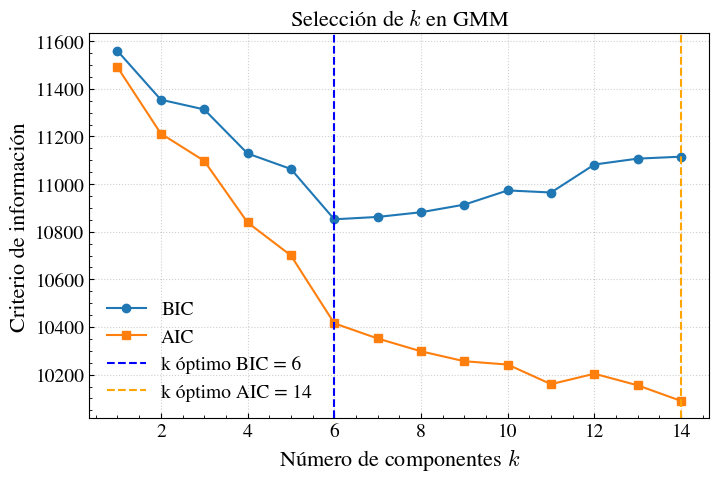


  Criterio     k óptimo
-------------------------
       BIC            6
       AIC           14


In [33]:
from sklearn.mixture import GaussianMixture

Ks = range(1, 15)
bics, aics = [], []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=42)
    gmm.fit(X_pca4)
    bics.append(gmm.bic(X_pca4))
    aics.append(gmm.aic(X_pca4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ks, bics, 'o-', label='BIC')
ax.plot(Ks, aics, 's-', label='AIC')
ax.axvline(Ks[np.argmin(bics)], color='blue', linestyle='--',
           label=f'k óptimo BIC = {Ks[np.argmin(bics)]}')
ax.axvline(Ks[np.argmin(aics)], color='orange', linestyle='--',
           label=f'k óptimo AIC = {Ks[np.argmin(aics)]}')
ax.set_xlabel('Número de componentes $k$')
ax.set_ylabel('Criterio de información')
ax.set_title('Selección de $k$ en GMM')
ax.legend(frameon=False)
ax.grid()
plt.show()

print(f"\n{'Criterio':>10}   {'k óptimo':>10}")
print("-" * 25)
print(f"{'BIC':>10}   {Ks[np.argmin(bics)]:>10}")
print(f"{'AIC':>10}   {Ks[np.argmin(aics)]:>10}")

BIC penaliza más fuertemente la complejidad (tiene factor $\ln(n)$ vs $2$ del AIC). Con $n=1000$, $\ln(1000) \approx 6.9$ — casi 3.5 veces más penalización que AIC. Por eso BIC dice "suficiente con $k=6$".

AIC penaliza menos y sigue bajando hasta $k=14$ (el límite que pusiste). Esto significa que según AIC, el modelo gana suficiente verosimilitud al añadir más componentes como para justificar los parámetros extra.

| Criterio | Filosofía | Cuándo usarlo |
|----------|-----------|---------------|
| **BIC** | Modelo más parsimonioso | Quieres interpretación física |
| **AIC** | Mejor ajuste predictivo | Quieres el mejor modelo predictivo |


Para este análisis el BIC es más apropiado — buscamos estructura física interpretable (C vs S), no el mejor modelo predictivo. $k=6$ con BIC es razonable: podría estar capturando subtipos dentro de C y S.

AIC con $k=14$ seguramente está sobreajustando — fragmentando grupos reales en subgrupos sin significado físico. Puedes verificarlo extendiendo el rango hasta $k=20$ — si AIC sigue bajando, confirma que está sobreajustando

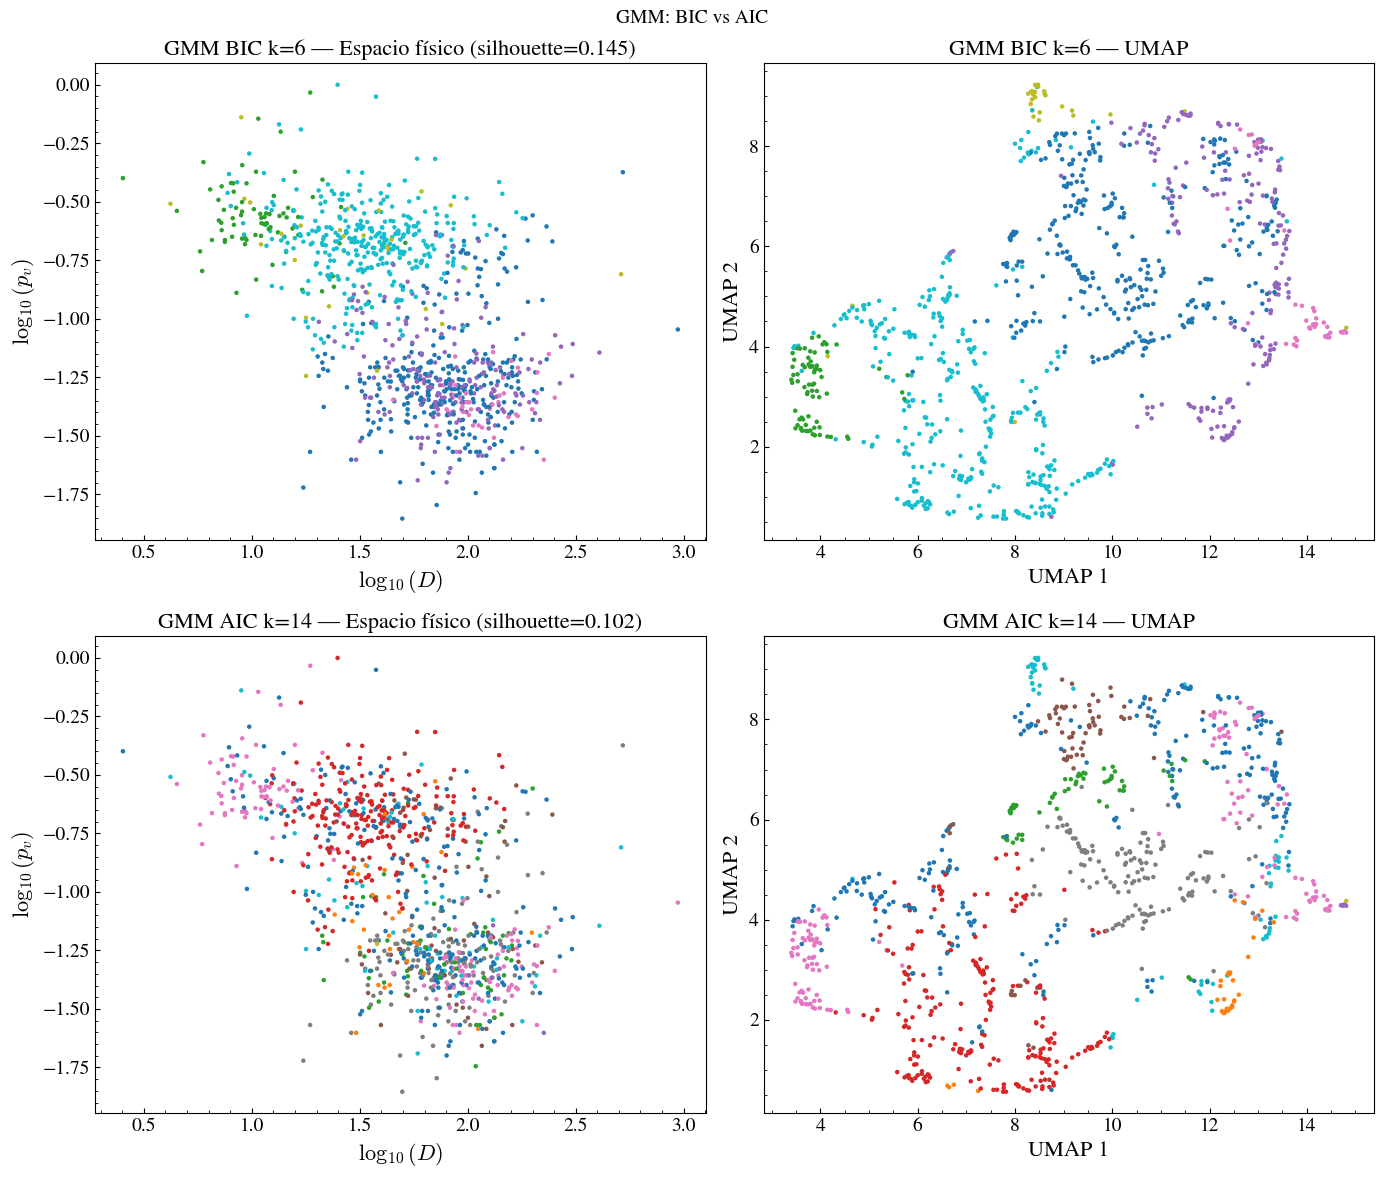

In [ ]:
from sklearn.mixture import GaussianMixture

k_bic = Ks[np.argmin(bics)]  # ya calculado antes
k_aic = Ks[np.argmin(aics)]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for row, (k, criterio) in enumerate([(k_bic, 'BIC'), (k_aic, 'AIC')]):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=42)
    labels = gmm.fit_predict(X_pca4)
    score = silhouette_score(X_pca4, labels)

    # Espacio físico
    axes[row, 0].scatter(df['logD'], df['logpv'], c=labels, s=5, cmap='tab10')
    axes[row, 0].set_xlabel(r'$\log_{10}(D)$')
    axes[row, 0].set_ylabel(r'$\log_{10}(p_v)$')
    axes[row, 0].set_title(f'GMM {criterio} k={k} — Espacio físico (silhouette={score:.3f})')

    # UMAP
    axes[row, 1].scatter(embedding_pca[:, 0], embedding_pca[:, 1],
                         c=labels, s=5, cmap='tab10')
    axes[row, 1].set_xlabel('UMAP 1')
    axes[row, 1].set_ylabel('UMAP 2')
    axes[row, 1].set_title(f'GMM {criterio} k={k} — UMAP')

plt.suptitle('GMM: BIC vs AIC', fontsize=14)
plt.tight_layout()
plt.show()

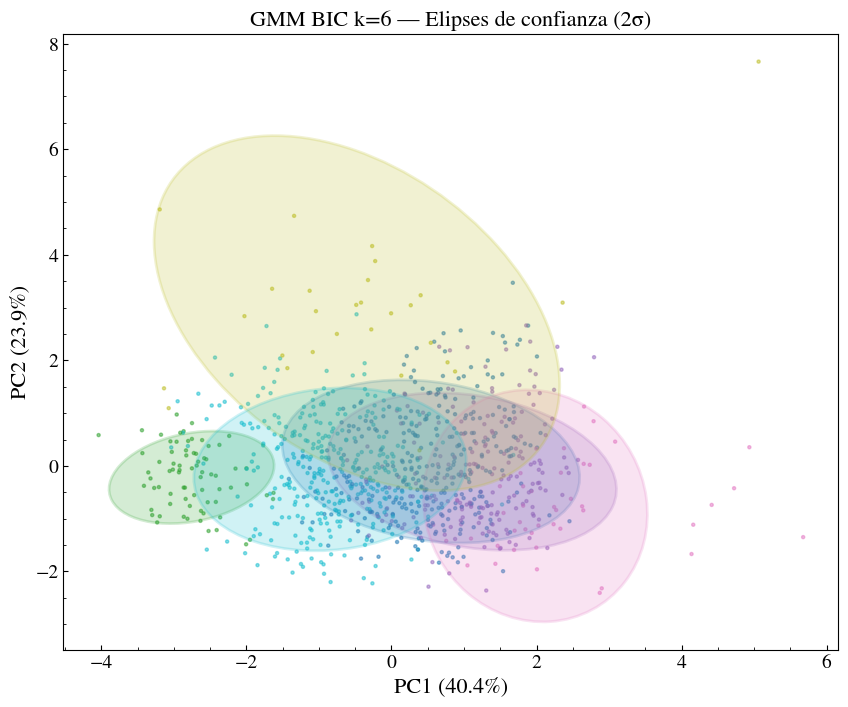

In [35]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_ellipse(ax, mean, cov, color, n_std=2):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(mean, width, height, angle=angle,
                      facecolor=color, alpha=0.2, edgecolor=color, lw=2)
    ax.add_patch(ellipse)

gmm_bic = GaussianMixture(n_components=k_bic, covariance_type='full',
                           n_init=5, random_state=42)
gmm_bic.fit(X_pca4)
labels = gmm_bic.predict(X_pca4)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, k_bic))

ax.scatter(X_pca4[:, 0], X_pca4[:, 1], c=labels, s=5, cmap='tab10', alpha=0.5)

for k, color in enumerate(colors):
    mean2d = gmm_bic.means_[k, :2]
    cov2d  = gmm_bic.covariances_[k, :2, :2]
    plot_ellipse(ax, mean2d, cov2d, color)

ax.set_xlabel(f'PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'GMM BIC k={k_bic} — Elipses de confianza (2σ)')
plt.show()


GMM k=6 — Soft Clustering


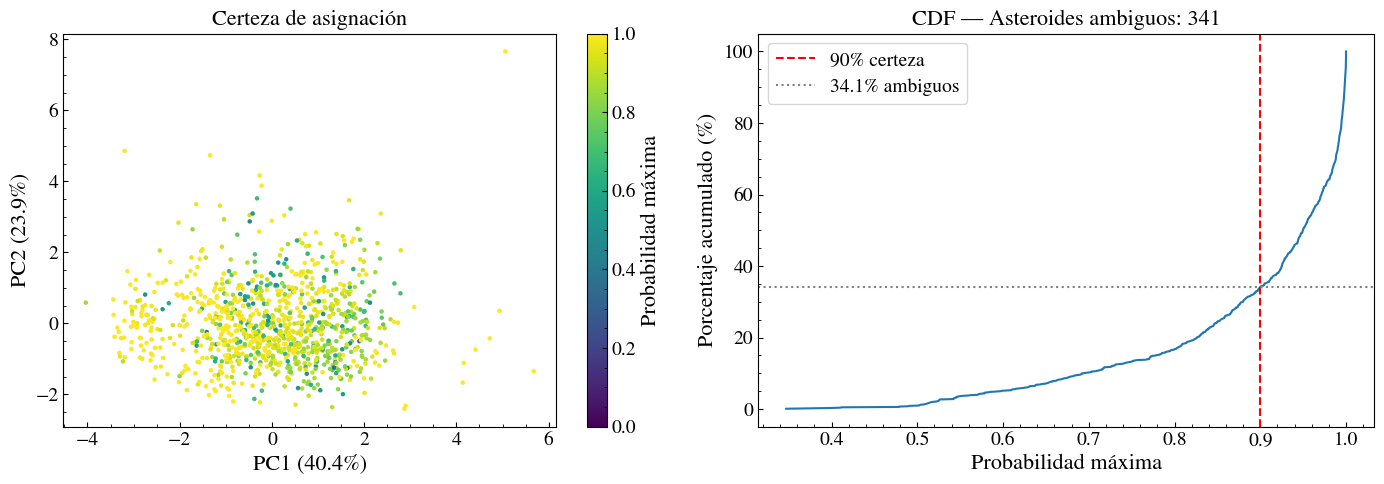

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Certeza en espacio PCA
sc = axes[0].scatter(X_pca4[:, 0], X_pca4[:, 1],
                     c=max_prob, s=5, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], label='Probabilidad máxima')
axes[0].set_xlabel(f'PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Certeza de asignación')

# CDF acumulativa
sorted_probs = np.sort(max_prob)
cdf = np.arange(1, len(sorted_probs)+1) / len(sorted_probs)
frac_ambiguos = (max_prob < 0.9).sum() / len(max_prob)

axes[1].plot(sorted_probs, cdf * 100)
axes[1].axvline(0.9, color='red', linestyle='--', label='90% certeza')
axes[1].axhline(frac_ambiguos * 100, color='gray', linestyle=':',
                label=f'{frac_ambiguos*100:.1f}% ambiguos')
axes[1].set_xlabel('Probabilidad máxima')
axes[1].set_ylabel('Porcentaje acumulado (%)')
axes[1].set_title(f'CDF — Asteroides ambiguos: {(max_prob < 0.9).sum()}')
axes[1].legend()

print(f'GMM k={k_bic} — Soft Clustering')
plt.tight_layout()
plt.show()


| `covariance_type` | $\boldsymbol{\Sigma}_k$ | Forma del cluster | Parámetros |
|---|---|---|---|
| `'spherical'` | $\sigma_k^2 \mathbf{I}$ | Círculo (= K-means soft) | $K$ |
| `'diag'` | $\text{diag}(\sigma_{k1}^2, \dots)$ | Elipse alineada a ejes | $K \times D$ |
| `'tied'` | $\boldsymbol{\Sigma}$ (compartida) | Misma forma, distinta posición | $\frac{D(D+1)}{2}$ |
| `'full'` | $\boldsymbol{\Sigma}_k$ libre | Elipse cualquier orientación | $K \times \frac{D(D+1)}{2}$ |

La matriz de covarianza $\boldsymbol{\Sigma}_k$ tiene una interpretación geométrica directa a través de sus autovalores y autovectores — conectando con el PCA que ya vimos:

$$\boldsymbol{\Sigma}_k = \mathbf{V}_k \boldsymbol{\Lambda}_k \mathbf{V}_k^T$$

donde:

- $\mathbf{V}_k$: autovectores → orientación de la elipse
- $\boldsymbol{\Lambda}_k = \text{diag}(\lambda_1, \dots, \lambda_D)$: autovalores → tamaño de cada eje ($\sqrt{\lambda_i}$ = radio)

Esto hace que cada tipo de covarianza imponga restricciones distintas:

| `covariance_type` | Autovectores $\mathbf{V}_k$ | Autovalores $\boldsymbol{\Lambda}_k$ | Restricción |
|---|---|---|---|
| `'spherical'` | Libres (irrelevantes) | $\lambda_1 = \lambda_2 = \cdots = \sigma_k^2$ | Todos los ejes iguales |
| `'diag'` | Fijos (ejes coordenados) | $\lambda_i$ libres | Sin rotación |
| `'tied'` | Compartidos entre clusters | Compartidos entre clusters | Misma forma para todos |
| `'full'` | Libres por cluster | Libres por cluster | Sin restricciones |

Para asteroides, 'full' es el más apropiado porque las familias dinámicas tienen correlaciones entre a, e y sin i — sus elipses están rotadas respecto a los ejes coordenados, algo que 'spherical' y 'diag' no pueden capturar.

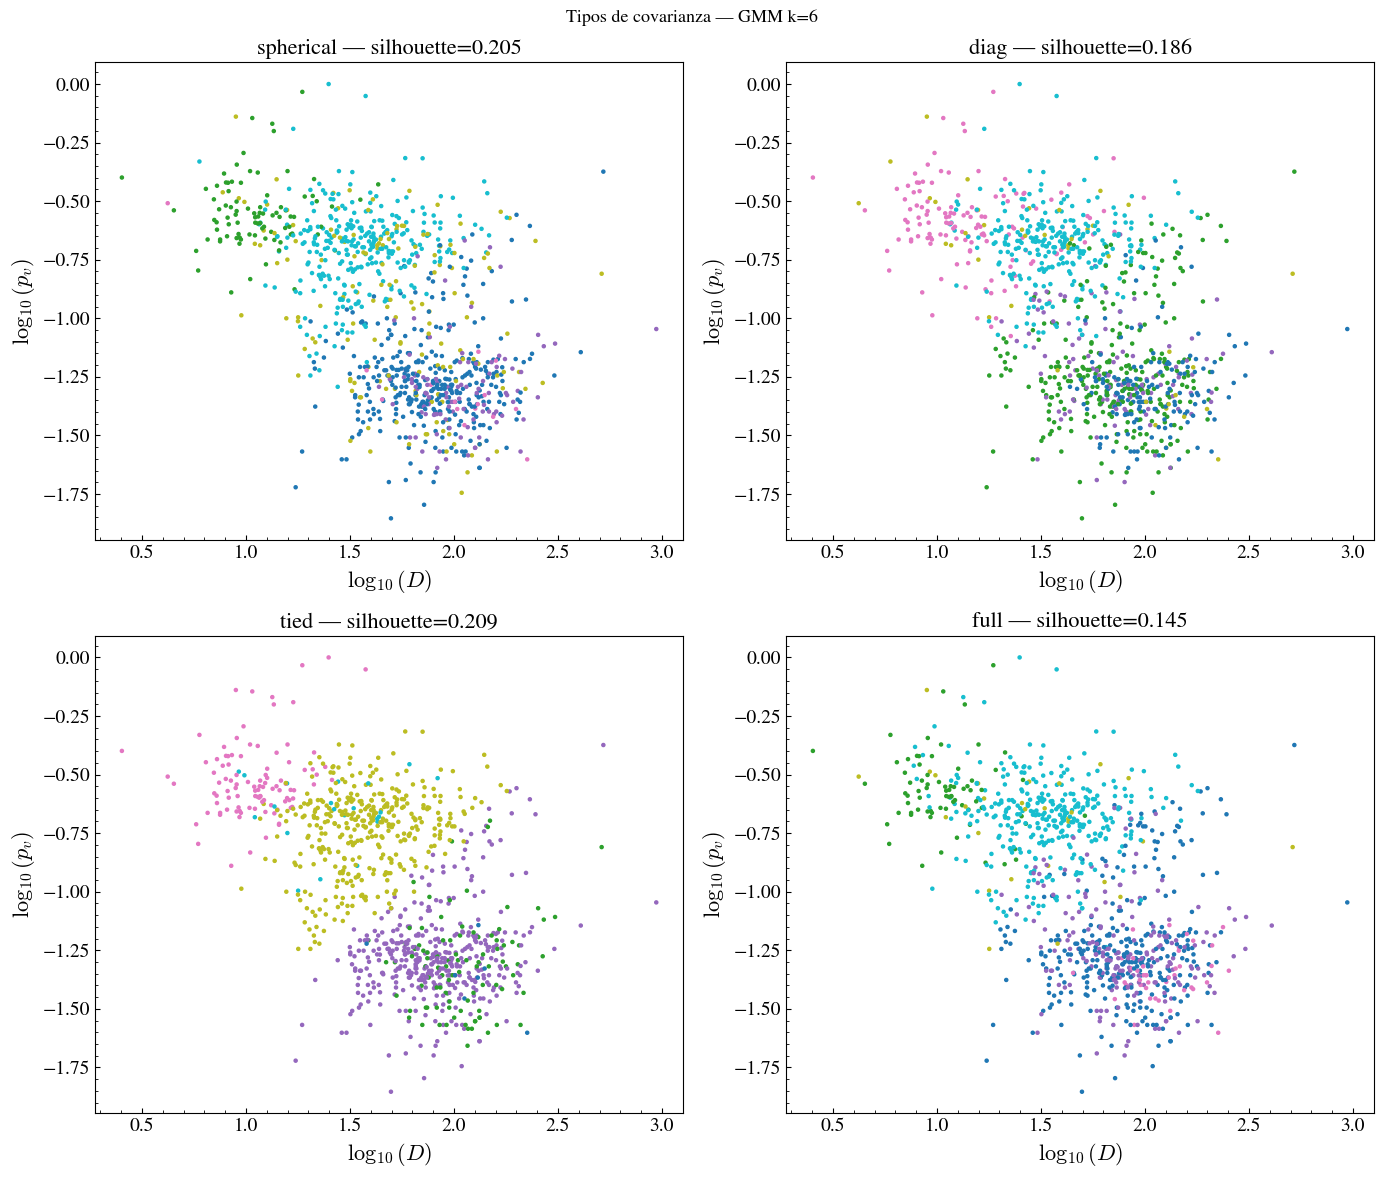

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, cov_type in zip(axes.flat,
                        ['spherical', 'diag', 'tied', 'full']):
    gmm = GaussianMixture(n_components=k_bic, covariance_type=cov_type,
                          n_init=5, random_state=42)
    labels = gmm.fit_predict(X_pca4)
    score = silhouette_score(X_pca4, labels)
    ax.scatter(df['logD'], df['logpv'], c=labels, s=5, cmap='tab10')
    ax.set_title(f'{cov_type} — silhouette={score:.3f}')
    ax.set_xlabel(r'$\log_{10}(D)$')
    ax.set_ylabel(r'$\log_{10}(p_v)$')

plt.suptitle(f'Tipos de covarianza — GMM k={k_bic}', fontsize=13)
plt.tight_layout()
plt.show()


## Clustering Herarchical

**Distancia:** Primero, necesitamos una forma de medir qué tan lejos están dos asteroides $i$ y $j$. La más común es la Distancia Euclídea:

$$d(x_i, x_j) = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

Donde $p$ son nuestras características ($a, e, i$, etc.)

**Criterios de Enlace (Linkage):** Aquí es donde reside la verdadera matemática del algoritmo. Una vez que sabemos la distancia entre puntos, ¿cómo medimos la distancia entre grupos de puntos (clústeres)?

- **Single Linkage (Enlace Simple):** Distancia mínima entre un punto del clúster A y uno del B. Tiende a crear clústeres alargados ("encadenamiento").
$$D(A, B) = \min \{d(a, b) : a \in A, b \in B\}$$
- **Complete Linkage (Enlace Completo):** Distancia máxima. Produce clústeres compactos y esféricos.
$$D(A, B) = \max \{d(a, b) : a \in A, b \in B\}$$

- **Average Linkage (Enlace Promedio):** Promedio de todas las distancias par a par.
$$D(A, B) = \frac{1}{|A||B|} \sum_{a \in A} \sum_{b \in B} d(a, b)$$

**Ward's Method:** Minimiza el incremento en la varianza total dentro de los clústeres al fusionarlos. Es el más robusto y común en astronomía porque busca clústeres densos y bien separados.

---

**El Dendrograma:** La Genealogía de los Datos. Un dendrograma es un diagrama de árbol que registra las fusiones.
- **Eje X:** Representa los objetos o clústeres individuales.
- **Eje Y:** Representa la distancia (o disimilitud) a la que se ocurrió la fusión.

Interpretación: Cuanto más alta sea la "U" invertida que une dos grupos, más diferentes son esos grupos entre sí.

Dado que los datos están estandarizados, la distancia euclidiana entre los asteroides $i$ y $j$ es:

$$d(\mathbf{x}i, \mathbf{x}j) = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

con $p=5$ features: $a,\ e,\ \sin i,\ \log D,\ \log p_v$.

Ejemplo numérico con 4 asteroides (features sin estandarizar para ilustrar):

|  | Ceres | Pallas | Vesta | Juno |
|--|-------|--------|-------|------|
| **Ceres** | 0 | 0.546 | 0.827 | 0.721 |
| **Pallas** | 0.546 | 0 | 0.760 | 0.501 |
| **Vesta** | 0.827 | 0.760 | 0 | 0.572 |
| **Juno** | 0.721 | 0.501 | 0.572 | 0 |


La distancia mínima es $d(\text{Pallas}, \text{Juno}) = 0.501$ → primera fusión.

Partiendo de la matriz de distancias anterior:

Paso 1 — mínimo global: $d(\text{Pallas}, \text{Juno}) = 0.501$ → fusionar $\{\text{Pallas, Juno}\}$

Actualizar distancias al nuevo cluster (mínimo de las dos):

$$d(\text{Ceres},\{\text{Pallas, Juno}\}) = \min(0.546,\ 0.721) = 0.546$$
$$d(\text{Vesta},\{\text{Pallas, Juno}\}) = \min(0.760,\ 0.572) = 0.572$$

Paso 2 — nuevo mínimo: $d(\text{Ceres},\ {\text{Pallas,Juno}}) = 0.546$ → fusionar $\{\text{Ceres, Pallas, Juno}\}$

Paso 3 — fusionar con Vesta a distancia $0.572$ → un solo cluster.

El dendrograma resultante:

```
Distancia
  0.572 ──────────────────────┐
  0.546 ──────────┐           │
  0.501 ──┐       │           │
          Pallas  Ceres      Vesta
          Juno
```

Una "U" alta entre grupos indica que son muy distintos — en este caso Vesta se une al último, lo que refleja su albedo inusualmente alto ($p_v = 0.42$) respecto al resto.

k óptimo: 4, umbral: 6.211


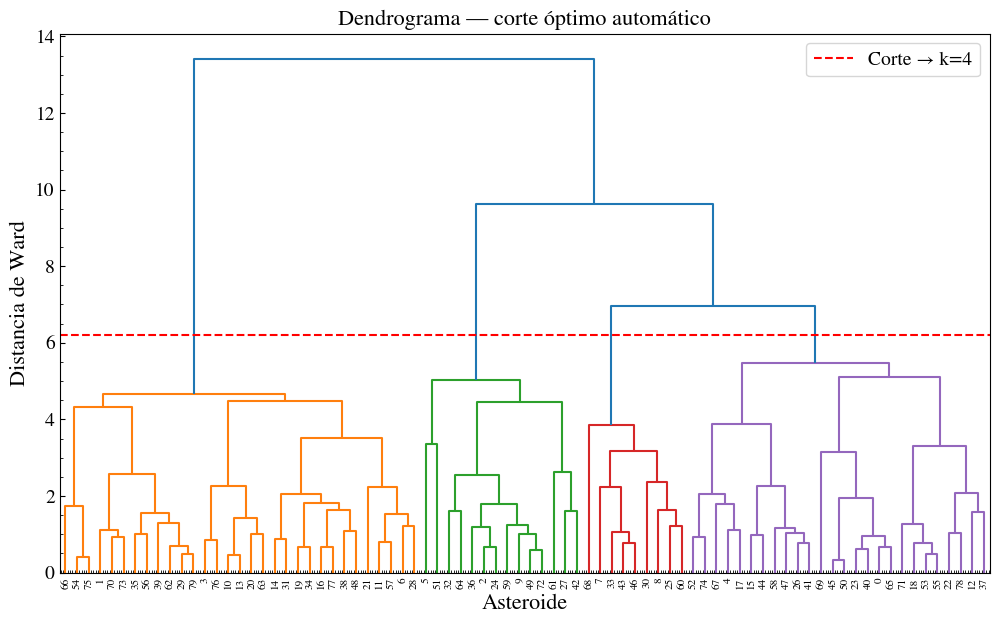

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage

idx = np.random.choice(len(X_scaled), size=80, replace=False)
X_sample = X_scaled[idx]
Z = linkage(X_sample, method='ward')

n_ultimas = 4  # solo el tope del árbol
ultimas_fusiones = Z[-n_ultimas:, 2]
aceleracion = np.diff(ultimas_fusiones)
k_optimo = aceleracion.argmax() + 2
umbral = (Z[-(k_optimo), 2] + Z[-(k_optimo-1), 2]) / 2


print(f'k óptimo: {k_optimo}, umbral: {umbral:.3f}')

plt.figure(figsize=(12, 7))
dendrogram(Z, leaf_rotation=90., leaf_font_size=8., color_threshold=umbral)
plt.axhline(y=umbral, color='r', linestyle='--', label=f'Corte → k={k_optimo}')
plt.xlabel('Asteroide')
plt.ylabel('Distancia de Ward')
plt.title('Dendrograma — corte óptimo automático')
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

metodos = ['ward', 'complete', 'average', 'single']
# Verificar el balance de los clusters
print('---- Without PCA ----')
for metodo in metodos:
    modelo = AgglomerativeClustering(n_clusters=2, linkage=metodo)
    labels = modelo.fit_predict(X_scaled)
    unique, counts = np.unique(labels, return_counts=True)
    score = silhouette_score(X_scaled, labels)
    print(f'{metodo:10s} → silhouette={score:.3f} | clusters: {counts}')

print()
print('---- With PCA ----')
for metodo in metodos:
    modelo = AgglomerativeClustering(n_clusters=2, linkage=metodo)
    labels = modelo.fit_predict(X_pca4)
    unique, counts = np.unique(labels, return_counts=True)
    score = silhouette_score(X_pca4, labels)
    print(f'{metodo:10s} → silhouette={score:.3f} | clusters: {counts}')



---- Without PCA ----
ward       → silhouette=0.215 | clusters: [527 473]
complete   → silhouette=0.743 | clusters: [999   1]
average    → silhouette=0.743 | clusters: [999   1]
single     → silhouette=0.743 | clusters: [999   1]

---- With PCA ----
ward       → silhouette=0.245 | clusters: [532 468]
complete   → silhouette=0.756 | clusters: [999   1]
average    → silhouette=0.756 | clusters: [999   1]
single     → silhouette=0.756 | clusters: [999   1]


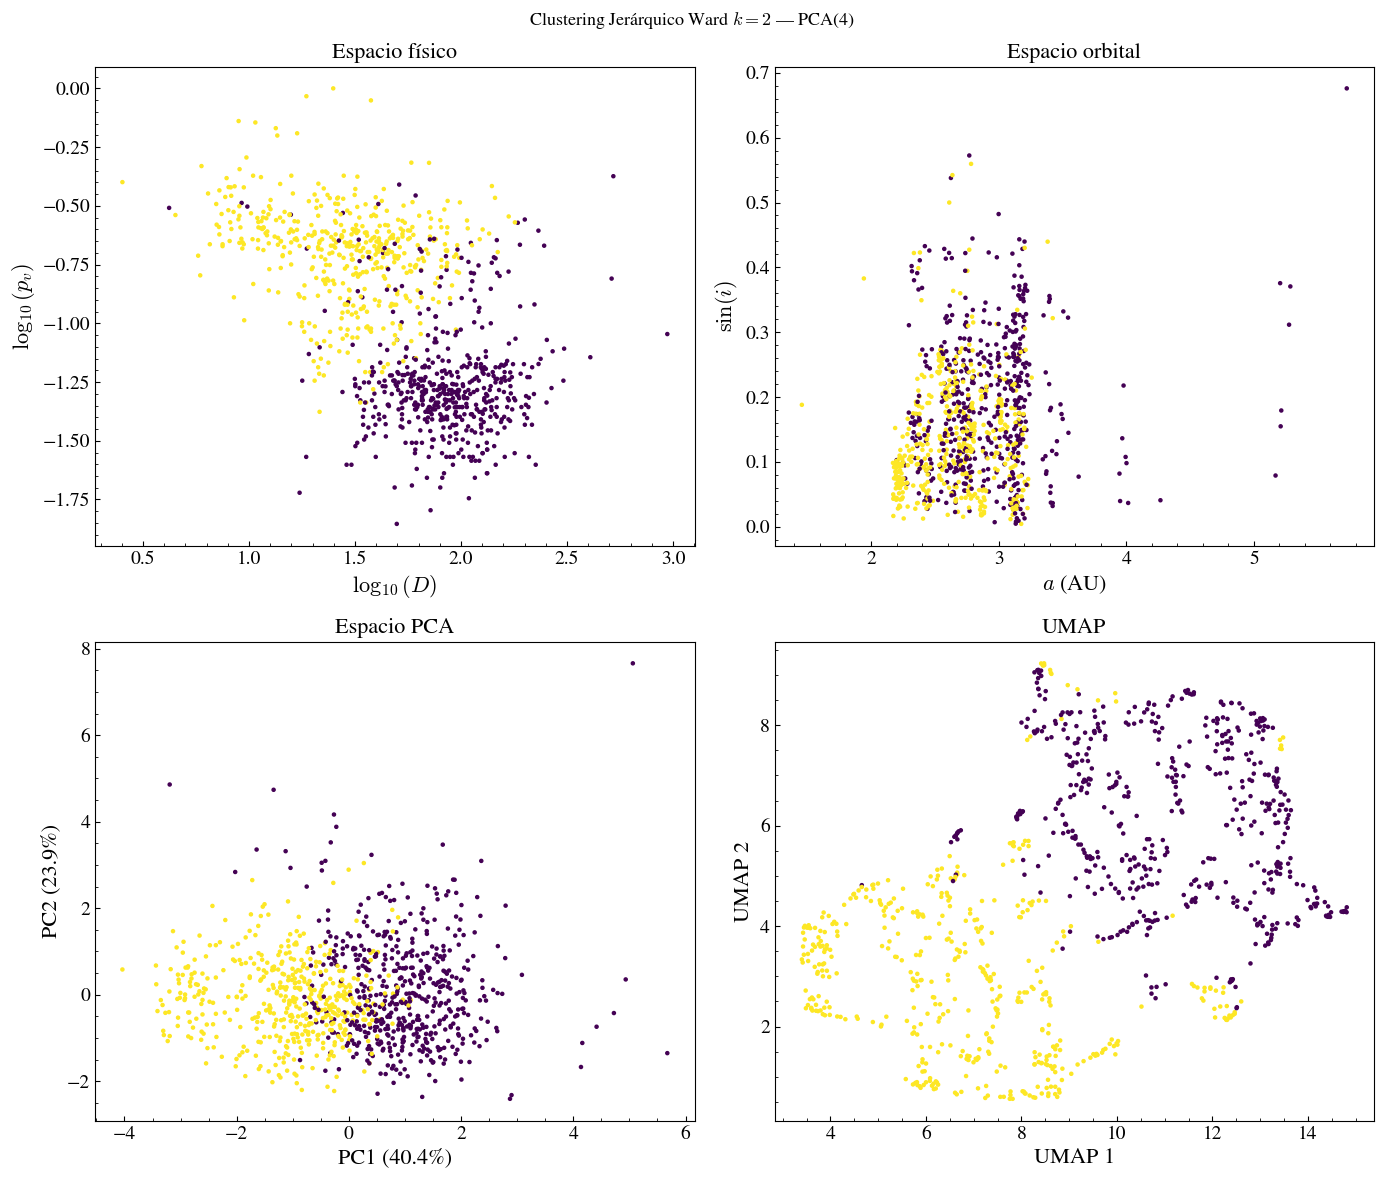

In [27]:
modelo = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['cluster_hier'] = modelo.fit_predict(X_pca4)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Espacio físico
axes[0,0].scatter(df['logD'], df['logpv'], c=df['cluster_hier'], s=5, cmap='viridis')
axes[0,0].set_xlabel(r'$\log_{10}(D)$')
axes[0,0].set_ylabel(r'$\log_{10}(p_v)$')
axes[0,0].set_title('Espacio físico')

# Espacio orbital
axes[0,1].scatter(df['a'], df['sini'], c=df['cluster_hier'], s=5, cmap='viridis')
axes[0,1].set_xlabel('$a$ (AU)')
axes[0,1].set_ylabel(r'$\sin(i)$')
axes[0,1].set_title('Espacio orbital')

# Espacio PCA
axes[1,0].scatter(X_pca4[:, 0], X_pca4[:, 1], c=df['cluster_hier'], s=5, cmap='viridis')
axes[1,0].set_xlabel(f'PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,0].set_ylabel(f'PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,0].set_title('Espacio PCA')

# UMAP
axes[1,1].scatter(embedding_pca[:, 0], embedding_pca[:, 1], c=df['cluster_hier'], s=5, cmap='viridis')
axes[1,1].set_xlabel('UMAP 1')
axes[1,1].set_ylabel('UMAP 2')
axes[1,1].set_title('UMAP')

plt.suptitle('Clustering Jerárquico Ward $k=2$ — PCA(4)', fontsize=13)
plt.tight_layout()
plt.show()


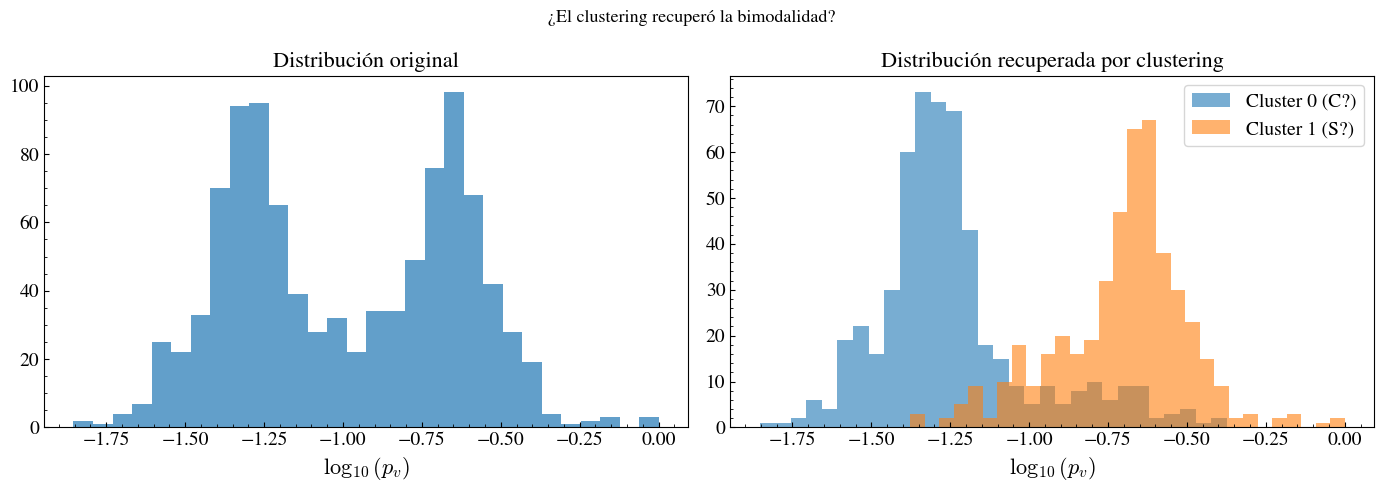

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma original
axes[0].hist(df['logpv'], bins=30, alpha=0.7)
axes[0].set_xlabel(r'$\log_{10}(p_v)$')
axes[0].set_title('Distribución original')

# Histograma separado por cluster
for cluster_id, color, label in zip([0, 1], ['C0', 'C1'], ['Cluster 0 (C?)', 'Cluster 1 (S?)']):
    mask = df['cluster_hier'] == cluster_id
    axes[1].hist(df.loc[mask, 'logpv'], bins=30, alpha=0.6, color=color, label=label)

axes[1].set_xlabel(r'$\log_{10}(p_v)$')
axes[1].set_title('Distribución recuperada por clustering')
axes[1].legend()

plt.suptitle('¿El clustering recuperó la bimodalidad?', fontsize=13)
plt.tight_layout()
plt.show()
